# Parameter Sweep: Monomial Family $V=A\phi^p$

Generalizes the quadratic ($p=2$) and quartic ($p=4$) potentials studied earlier into a continuous family, varying the power $p$. For every $p$, $\phi_i$ is found by root-finding on the **exact background ODE** (starting from the closed-form slow-roll guess $\phi_i=\sqrt{2p(N_{\rm end}+p/4)}$) to hit $N_{\rm end}=65$ exactly, and the amplitude $A$ is tuned to the shared pivot benchmark $\mathcal{P}_\mathcal{R}(k_*)=2.05\times10^{-9}$.

In [1]:
import numpy as np
from scipy import integrate
from scipy.integrate import solve_ivp
from scipy.optimize import brentq
import matplotlib.pyplot as plt

def background_eqn(N, fields, potential):
    phi, dphidN = fields
    v, dvdphi = potential(phi)
    d2phidN2 = -(3. - 0.5*(dphidN*dphidN))*dphidN \
               - (6. - (dphidN*dphidN))*dvdphi/(2.*v)
    return [dphidN, d2phidN2]

def Hubble(phi_N, V):
    return np.sqrt(V/(3 - 0.5*(phi_N*phi_N)))

def epsilon1(phi_N):
    return 0.5*phi_N*phi_N

def stop_integration(N, y):
    return 0.5*(y[1]**2) - 1
stop_integration.terminal = True
stop_integration.direction = 0

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]

def z_of(a, phi_N):
    return a*phi_N

def solve_background(potential, ph_initial, t_end=120.0, fine_step=2e-3):
    efolds_fine = np.arange(0, t_end, fine_step)
    sol = solve_ivp(lambda N, y: background_eqn(N, y, potential),
                     [0, t_end], ph_initial, method='RK45',
                     dense_output=True, events=(stop_integration,), max_step=np.inf)
    Nend = sol.t_events[0][0] if len(sol.t_events[0]) > 0 else sol.t[-1]
    mask = efolds_fine < Nend
    efolds = efolds_fine[mask]
    y = sol.sol(efolds)
    phi, dphi = y[0], y[1]
    pot, dpotdphi = potential(phi)
    Hub = Hubble(dphi, pot)
    return dict(efolds=efolds, phi=phi, dphi=dphi, pot=pot,
                dpotdphi=dpotdphi, Hub=Hub, Nend=Nend)

def pert_eqn(y, N, k, ai, potential):
    phi, dphidN, Rk_re, Rk_re_N, Rk_im, Rk_im_N, hk_re, hk_re_N, hk_im, hk_im_N = y
    v, dvdphi = potential(phi)
    d2phidN2 = -(3. - 0.5*(dphidN*dphidN))*dphidN - (6. - (dphidN*dphidN))*dvdphi/(2.*v)
    a = ai*np.exp(N)
    H = np.sqrt(v/(3 - 0.5*(dphidN*dphidN)))
    zN = a*(dphidN + d2phidN2)
    zval = z_of(a, dphidN)
    Rk_re_NN = -(1 - (dphidN**2)*0.5 + 2.0*(zN/zval))*Rk_re_N - ((k/(a*H))**2)*Rk_re
    Rk_im_NN = -(1 - (dphidN**2)*0.5 + 2.0*(zN/zval))*Rk_im_N - ((k/(a*H))**2)*Rk_im
    hk_re_NN = -(3 - (dphidN**2)*0.5)*hk_re_N - ((k/(a*H))**2)*hk_re
    hk_im_NN = -(3 - (dphidN**2)*0.5)*hk_im_N - ((k/(a*H))**2)*hk_im
    return [dphidN, d2phidN2, Rk_re_N, Rk_re_NN, Rk_im_N, Rk_im_NN,
            hk_re_N, hk_re_NN, hk_im_N, hk_im_NN]

def boundary(k, t, aH, Nic_cond, Nshs_cond):
    ic_diff = k - Nic_cond*aH
    shs_diff = k - Nshs_cond*aH
    idx_ic, _ = find_nearest(ic_diff, 0)
    idx_shs, _ = find_nearest(shs_diff, 0)
    return idx_ic, t[idx_ic], t[idx_shs]

def initial_condition(idx_ic, k, efolds, phi, dphi, ai, Hub, potential):
    phi_ic = phi[idx_ic]; phiN_ic = dphi[idx_ic]
    a_ic = ai*np.exp(efolds[idx_ic]); z_ic = z_of(a_ic, phiN_ic); H_ic = Hub[idx_ic]
    _, phiNN_ic = background_eqn(efolds[idx_ic], [phi_ic, phiN_ic], potential)
    Rk_re_ic = (1/(np.sqrt(2*k)))/z_ic
    Rk_im_ic = 0
    Rk_re_N_ic = -Rk_re_ic*((phiNN_ic/phiN_ic) + 1)
    Rk_im_N_ic = -np.sqrt(k/2)/(a_ic*H_ic*z_ic)
    hk_re_ic = (1/(np.sqrt(2*k)))/a_ic
    hk_im_ic = 0
    hk_re_N_ic = -hk_re_ic
    hk_im_N_ic = -np.sqrt(k/2)/(a_ic*H_ic*a_ic)
    return [phi_ic, phiN_ic, Rk_re_ic, Rk_re_N_ic, Rk_im_ic, Rk_im_N_ic,
            hk_re_ic, hk_re_N_ic, hk_im_ic, hk_im_N_ic]

def Psk(kk, Rk):
    Rk_re, Rk_im = Rk
    return kk**3/(2e0*np.pi**2)*((Rk_re*Rk_re)+(Rk_im*Rk_im))

def Pth(kk, hk):
    hk_re, hk_im = hk
    return 8.0*kk**3/(2e0*np.pi**2)*((hk_re*hk_re)+(hk_im*hk_im))

class InflationRun:
    def __init__(self, potential, bg, kpivot=0.05, Nic_cond=100, Nshs_cond=1e-5):
        self.potential = potential
        self.efolds = bg['efolds']; self.phi = bg['phi']; self.dphi = bg['dphi']
        self.Hub = bg['Hub']; self.Nend = bg['Nend']
        self.Nic_cond = Nic_cond; self.Nshs_cond = Nshs_cond
        idx50, Ne50 = find_nearest(self.efolds, self.Nend - 50)
        self.idx50, self.Ne50 = idx50, Ne50
        self.ai = kpivot/(np.exp(Ne50)*self.Hub[idx50])
        self.kpivot = kpivot

    def compute_pps(self, kk, atol=1e-11):
        idx_ic, Nic, Nshs = boundary(kk, self.efolds, self.ai*np.exp(self.efolds)*self.Hub,
                                      self.Nic_cond, self.Nshs_cond)
        efolds_pert = np.arange(Nic, Nshs, 0.01)
        pert_ic = initial_condition(idx_ic, kk, self.efolds, self.phi, self.dphi,
                                     self.ai, self.Hub, self.potential)
        sol_pert = integrate.odeint(pert_eqn, pert_ic, efolds_pert,
                                     args=(kk, self.ai, self.potential), atol=atol)
        Rkshs = [sol_pert[-1,2], sol_pert[-1,4]]
        hkshs = [sol_pert[-1,6], sol_pert[-1,8]]
        return Psk(kk, Rkshs), Pth(kk, hkshs), efolds_pert, sol_pert, Nic, Nshs


In [2]:
def monomial_potential(phi, p, A):
    v = A*phi**p
    dv = A*p*phi**(p-1)
    return v, dv

def eps_eta_monomial(phi, p):
    return p**2/(2*phi**2), p*(p-1)/phi**2

TARGET_NEND = 65.0
TARGET_AS = 2.05e-9
KPIVOT = 0.05

def calibrate_monomial(p):
    A0 = 1e-12
    pot0 = lambda phi: monomial_potential(phi, p, A0)
    guess = np.sqrt(2*p*(TARGET_NEND + p/4))
    def Nend_of_phi(phi_i):
        ph=[phi_i, None]; V,dV = pot0(phi_i); ph[1]=-dV/V
        return solve_background(pot0, ph, t_end=150)['Nend']
    phi_i = brentq(lambda ph: Nend_of_phi(ph)-TARGET_NEND, guess*0.7, guess*1.3, xtol=1e-7)

    ph=[phi_i, None]; V,dV = pot0(phi_i); ph[1]=-dV/V
    bg = solve_background(pot0, ph, t_end=150, fine_step=5e-4)
    run = InflationRun(pot0, bg, kpivot=KPIVOT, Nic_cond=100)
    pps0, ppt0, *_ = run.compute_pps(KPIVOT)
    A_new = A0*np.sqrt(TARGET_AS/pps0)   # PPS ~ A for monomials with this normalization

    pot1 = lambda phi: monomial_potential(phi, p, A_new)
    ph1=[phi_i, None]; V1,dV1 = pot1(phi_i); ph1[1]=-dV1/V1
    bg1 = solve_background(pot1, ph1, t_end=150, fine_step=5e-4)
    run1 = InflationRun(pot1, bg1, kpivot=KPIVOT, Nic_cond=100)
    pps1, ppt1, *_ = run1.compute_pps(KPIVOT)
    r_num = ppt1/pps1

    phi_star = bg1['phi'][run1.idx50]
    eps_v, eta_v = eps_eta_monomial(phi_star, p)
    ns_analytic = 1 - 6*eps_v + 2*eta_v
    r_analytic = 16*eps_v

    return dict(p=p, phi_i=phi_i, A=A_new, Nend=bg1['Nend'],
                ns_analytic=ns_analytic, r_analytic=r_analytic,
                r_numerical=r_num, eps_v=eps_v, eta_v=eta_v)

## Run the sweep

In [3]:
p_values = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0])
results = [calibrate_monomial(p) for p in p_values]

print(f"{'p':>5} {'phi_i':>10} {'N_end':>8} {'n_s (SR)':>10} {'r (SR)':>10} {'r (num)':>10}")
for r in results:
    print(f"{r['p']:>5.1f} {r['phi_i']:>10.4f} {r['Nend']:>8.3f} {r['ns_analytic']:>10.4f} {r['r_analytic']:>10.5f} {r['r_numerical']:>10.5f}")

    p      phi_i    N_end   n_s (SR)     r (SR)    r (num)
  1.0    11.3304   65.000     0.9695    0.08125    0.07951
  1.5    13.8901   65.000     0.9645    0.12157    0.11897
  2.0    16.0548   65.000     0.9596    0.16168    0.15823
  2.5    17.9676   65.000     0.9546    0.20157    0.19728
  3.0    19.7023   65.000     0.9497    0.24126    0.23612
  3.5    21.3022   65.000     0.9449    0.28074    0.27476
  4.0    22.7957   65.000     0.9400    0.32001    0.31321
  4.5    24.2027   65.000     0.9352    0.35908    0.35145
  5.0    25.5377   65.000     0.9304    0.39793    0.38948
  5.5    26.8110   65.000     0.9256    0.43659    0.42733
  6.0    28.0304   65.000     0.9208    0.47508    0.46501


## Plots: how $n_s$, $r$, and $\phi_i$ vary with $p$

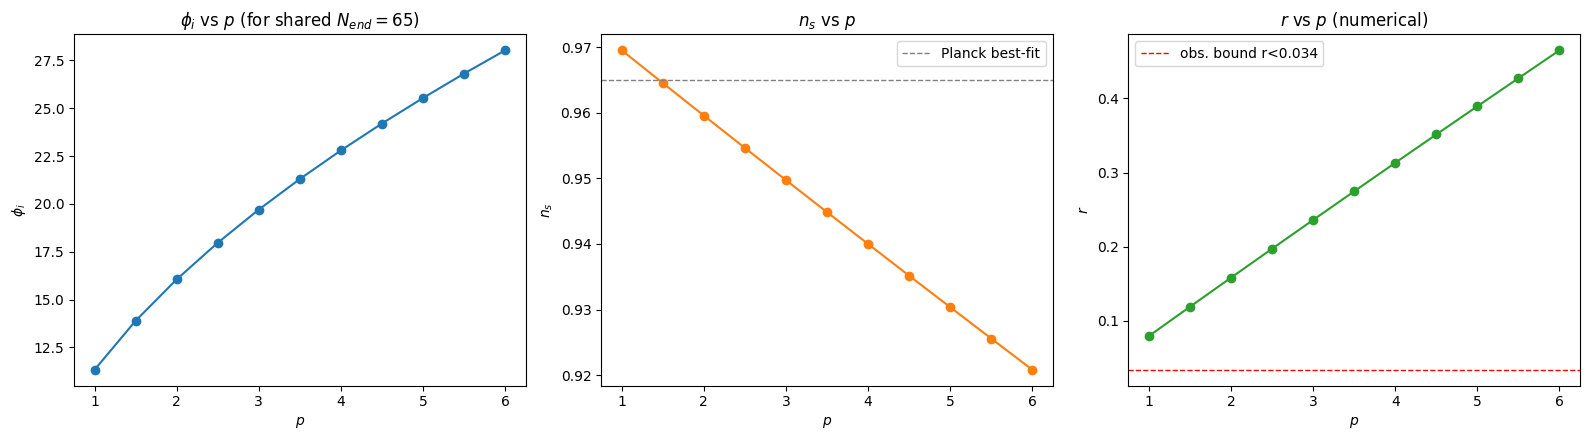

In [4]:
ps = [r['p'] for r in results]
ns_vals = [r['ns_analytic'] for r in results]
r_vals = [r['r_numerical'] for r in results]
phi_i_vals = [r['phi_i'] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(16,4.5))
axes[0].plot(ps, phi_i_vals, 'o-')
axes[0].set_xlabel('$p$'); axes[0].set_ylabel(r'$\phi_i$')
axes[0].set_title(r'$\phi_i$ vs $p$ (for shared $N_{end}=65$)')

axes[1].plot(ps, ns_vals, 'o-', color='C1')
axes[1].axhline(0.965, ls='--', color='gray', lw=1, label='Planck best-fit')
axes[1].set_xlabel('$p$'); axes[1].set_ylabel('$n_s$')
axes[1].set_title('$n_s$ vs $p$'); axes[1].legend()

axes[2].plot(ps, r_vals, 'o-', color='C2')
axes[2].axhline(0.034, ls='--', color='red', lw=1, label='obs. bound r<0.034')
axes[2].set_xlabel('$p$'); axes[2].set_ylabel('$r$')
axes[2].set_title('$r$ vs $p$ (numerical)'); axes[2].legend()
plt.tight_layout(); plt.show()

## The $(n_s, r)$ track traced out by this family

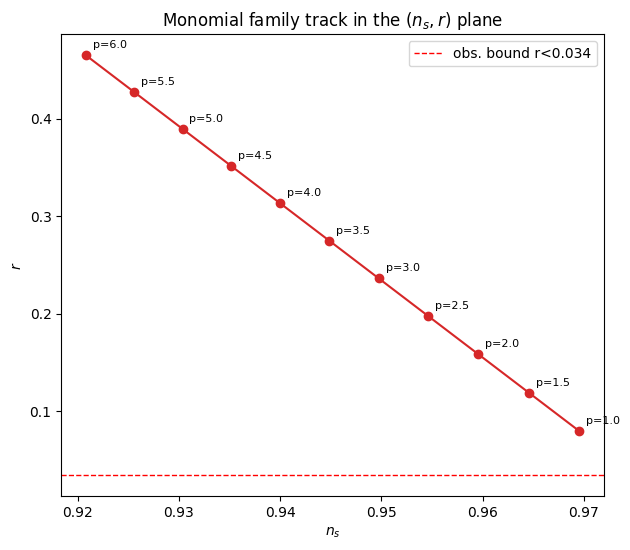

In [5]:
plt.figure(figsize=(7,6))
plt.plot(ns_vals, r_vals, 'o-', color='C3')
for r in results:
    plt.annotate(f"p={r['p']:.1f}", (r['ns_analytic'], r['r_numerical']), fontsize=8,
                 textcoords='offset points', xytext=(5,5))
plt.xlabel('$n_s$'); plt.ylabel('$r$')
plt.title('Monomial family track in the $(n_s,r)$ plane')
plt.axhline(0.034, ls='--', color='red', lw=1, label='obs. bound r<0.034')
plt.legend(); plt.show()